# Generating image subregions through average greyscale image

Based on: A Transfer Learning Method for Meteorological Visibility Estimation Based on Feature Fusion Method

In [84]:
import os
import cv2
import sqlite3
import numpy as np
import json
from matplotlib import pyplot as plt
from pathlib import Path
from fogvis.db import ImageEntity, Database
from scipy.stats import norm 
from dataclasses import dataclass, asdict

#assuming default import media location
DB_PATH : Path = Path(os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir, "media", "db", "database.sqlite3")))
PRE_MASK_GREY_VALUE_CLIP = 254
NUM_SUBREGIONS_TO_SELECT = 5
GLOBAL_CANDIDATE_T_VALUES = [235]

Will first need to import all of the images for a given camera angle in a database

In [96]:
def get_test_camera_id(db : Database) -> int: 
    id = 0

    with db as conn: 
        sql = "SELECT id from camera LIMIT 1"
        cur = conn.cursor()
        result = cur.execute(sql).fetchone()

        if result is None: 
            raise Exception("Failed to get camera id")
        camera_id = result[0]

        return camera_id

def get_images_for_one_camera_angle(db : Database) -> tuple[list[Path], int]:
    image_paths : list[Path] = []

    test_camera_id = 1441
    with db as conn: 
        sql = f"SELECT filePath from image WHERE cameraID = {test_camera_id}"

        result = conn.execute(sql).fetchall()

        if result is None: 
            raise Exception()
        
        for r in result: 
            name = r[0]
            fPath : Path = Path(os.path.join(Path(db.db_path).parent, "images", name))
            image_paths.append(fPath)

    return (image_paths, test_camera_id)
    
print(DB_PATH)
test_images, test_camera_id = get_images_for_one_camera_angle(Database(DB_PATH))
test_images

e:\Repos\FoggyVision\media\db\database.sqlite3


[WindowsPath('e:/Repos/FoggyVision/media/db/images/2026-05-03_13-38-07_Frame-0.png'),
 WindowsPath('e:/Repos/FoggyVision/media/db/images/2026-05-03_13-38-07_Frame-1.png'),
 WindowsPath('e:/Repos/FoggyVision/media/db/images/2026-05-03_13-38-07_Frame-10.png'),
 WindowsPath('e:/Repos/FoggyVision/media/db/images/2026-05-03_13-38-07_Frame-11.png'),
 WindowsPath('e:/Repos/FoggyVision/media/db/images/2026-05-03_13-38-07_Frame-12.png'),
 WindowsPath('e:/Repos/FoggyVision/media/db/images/2026-05-03_13-38-07_Frame-13.png'),
 WindowsPath('e:/Repos/FoggyVision/media/db/images/2026-05-03_13-38-07_Frame-14.png'),
 WindowsPath('e:/Repos/FoggyVision/media/db/images/2026-05-03_13-38-07_Frame-15.png'),
 WindowsPath('e:/Repos/FoggyVision/media/db/images/2026-05-03_13-38-07_Frame-16.png'),
 WindowsPath('e:/Repos/FoggyVision/media/db/images/2026-05-03_13-38-07_Frame-17.png'),
 WindowsPath('e:/Repos/FoggyVision/media/db/images/2026-05-03_13-38-07_Frame-18.png'),
 WindowsPath('e:/Repos/FoggyVision/media/db/i

### Comprehensive Image

In [98]:
def read_color_to_grey(path : Path): 
    img = cv2.imread(path)
    if img is None:
        raise Exception(f"Failed to read image {path}")
    
    grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return grey

def calculate_average_grey_image(image_paths : list[Path]) -> np.ndarray:
    first = read_color_to_grey(image_paths[0])
    
    if first is None:
        raise Exception("Failed to read first image")
    
    h,w = first.shape
    avg_image = np.zeros((h,w), dtype=np.float32)

    for path in image_paths:
        img = read_color_to_grey(path)

        if img.shape != (h,w): 
            raise ValueError(f"Image {path} has different size than expected")
        
        avg_image += img.astype(np.float32)

    avg_image /= len(image_paths)
    avg_image_uint8 = avg_image.astype(np.uint8)

    return avg_image_uint8

avg_image = calculate_average_grey_image(test_images)
avg_image_blurred = cv2.GaussianBlur(avg_image, (5,5), 0)

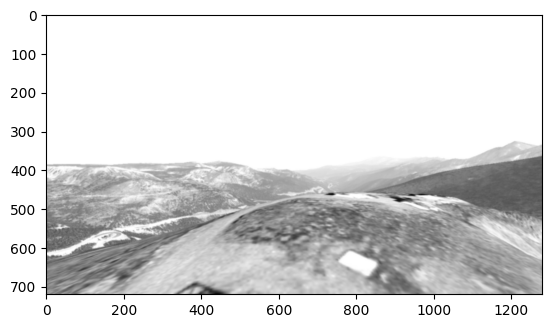

In [87]:
plt.imshow(avg_image_blurred, cmap="grey")
plt.show()

### Grey Level Distribution

The rendered images often have lots of pure white since the background is white. Going to try leaving out the pure whites from the distribution.

In [88]:
def calculate_grey_normal_distribution(image : np.ndarray, mask): 
    pixels = image.ravel()
    masked_pixels = pixels[mask]

    mean = np.mean(masked_pixels)
    std_dev = np.std(masked_pixels)

    return (mean, std_dev)

white_mask = avg_image.ravel() < PRE_MASK_GREY_VALUE_CLIP
mean,std = calculate_grey_normal_distribution(avg_image_blurred, white_mask)
mean,std

(np.float64(196.38860655756736), np.float64(26.071548275865638))

Looking at image normal distribution of pixels

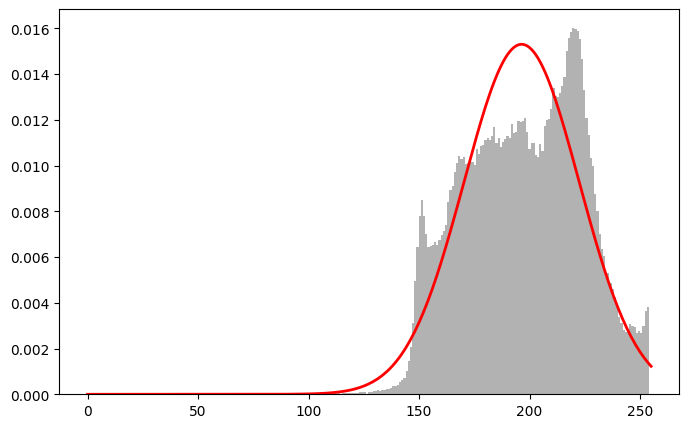

In [ ]:
pixels = avg_image_blurred.ravel()

# Create histogram
plt.figure(figsize=(8, 5))

plt.hist(
    pixels,
    bins=256,
    range=(0, 254),
    density=True,
    alpha=0.6,
    color="gray",
    label="Greyscale histogram"
)

# Create normal distribution curve
x = np.linspace(0, 255, 256)
gaussian_curve = norm.pdf(x, mean, std)

# Plot Gaussian curve
plt.plot(
    x,
    gaussian_curve,
    color="red",
    linewidth=2,
    label=f"Normal fit\nμ={mean:.2f}, σ={std:.2f}"
)
plt.show()

#### Subregion Extraction

In [90]:
def select_subregions(grey_image, N, candidate_cutoff_values : list[int]):
    best_mask = None
    best_T = None

    for T in candidate_cutoff_values:
        _, mask = cv2.threshold(grey_image, T, 255, cv2.THRESH_BINARY_INV)

        #use a simple foreground vs background heuristic to check if the candidate is good
        foreground_ratio = mask.mean() / 255.0
        print(foreground_ratio)
        if 0.05 < foreground_ratio < 0.8: 
            best_mask = mask
            best_T = T

    if best_mask is None:
        raise Exception("Failed to find proper candidate")
    
    rows = np.where(best_mask.any(axis=1))[0]
    y_min, y_max = rows[0], rows[-1]

    h,w = grey_image.shape
    sub_w = w // N
    usable_w = sub_w * N

    x0 = (w - usable_w)

    subregions = []
    for i in range(N):
        x1 = x0 + sub_w
        subregions.append((x0, y_min, x1, y_max))
        x0 = x1


    return subregions, best_T

subregions, selected_T = select_subregions(avg_image_blurred, NUM_SUBREGIONS_TO_SELECT, GLOBAL_CANDIDATE_T_VALUES)

0.44445638020833333


In [91]:
selected_T

235

In [92]:
subregions

[(0, np.int64(327), 256, np.int64(719)),
 (256, np.int64(327), 512, np.int64(719)),
 (512, np.int64(327), 768, np.int64(719)),
 (768, np.int64(327), 1024, np.int64(719)),
 (1024, np.int64(327), 1280, np.int64(719))]

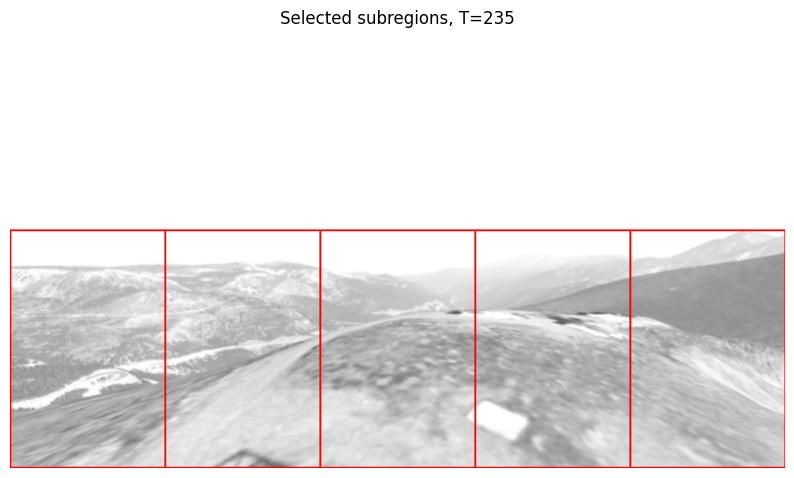

In [93]:
def draw_subregions(image, subregions, color=(0, 0, 255), thickness=2):
    """
    Draw horizontal subregions over an image.

    image:
        grayscale or BGR image

    subregions:
        list of (y0, y1) tuples

    color:
        rectangle color in BGR.
        Default (0, 0, 255) = red.

    thickness:
        line thickness
    """

    # Convert grayscale to BGR so colored rectangles can be drawn
    if len(image.shape) == 2:
        output = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    else:
        output = image.copy()

    height, width = output.shape[:2]

    for i, (x0, y0, x1, y1) in enumerate(subregions):
        # Draw rectangle spanning full image width
        cv2.rectangle(
            output,
            (x0, y0),
            (x1, y1),
            color,
            thickness
        )

    return output

overlay = draw_subregions(avg_image_blurred, subregions)
overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(overlay_rgb)
plt.title(f"Selected subregions, T={selected_T}")
plt.axis("off")
plt.show()

## Application Tie In Code

Write the regions out to disk as a json file along with the camera information

In [94]:
@dataclass
class Subregion: 
    x0 : str
    y0 : str
    x1 : str
    y1 : str

    def to_dict(self) -> dict: 
        return asdict(self)
    
    @classmethod
    def from_dict(cls, data : dict) -> "Subregion": 
        return cls(**data)
    
class ViewSubregionFile:
    def __init__(self, file_path: Path) -> None:
        self.file_path = file_path
        self.subregions: dict[int, list[Subregion]] = {}

    def add_subregion(self, camera_id: int, subregion: Subregion) -> None:
        self.subregions.setdefault(camera_id, []).append(subregion)

    def write(self) -> None:
        result = {
            camera_id: [sr.to_dict() for sr in subregion_list]
            for camera_id, subregion_list in self.subregions.items()
        }

        with open(self.file_path, "w", encoding="utf-8") as file:
            json.dump(result, file, indent=4)


jPath = Path(os.path.join(os.getcwd(), "subregions.json"))
subregionsFile = ViewSubregionFile(jPath)

for s in subregions: 
    subregionsFile.add_subregion(0, Subregion(str(s[0]), str(s[1]), str(s[2]), str(s[3])))

subregionsFile.write()